# **DATA CLEANING**

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read data into dataframe
df = pd.read_csv("Dataset.csv")
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
# data statistics
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
# Missing value Check
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Check Duplicates
print(df.duplicated().sum())

0


In [ ]:
# Impute Review Rating with median to handle missing values
df["Review Rating"] = (df["Review Rating"].fillna(df["Review Rating"].median()))

In [ ]:
# Standardize Frequency Categories
# (Bi-Weekly is same as Fortnightly. Similarly, Quarterly is same as Every 3 Months)
df["Frequency of Purchases"] = (df["Frequency of Purchases"].replace({"Bi-Weekly": "Fortnightly", "Every 3 Months": "Quarterly"}))

In [ ]:
# Recheck null values
print(df.isnull().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


# **EXPLORATORY DATA ANALYSIS**

In [ ]:
# Frequency of purchases is categorical. Converted into numerical feature by mapping it to frequency.
# weekly means 52 weeks in a year, monthly means 12 months in year and so on.
# Higher score = stronger engagement
freq_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

df["Frequency_Score"] = df["Frequency of Purchases"].map(freq_map)
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Frequency_Score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,26
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,26
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,52
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,52
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,1
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly,52
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly,4
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly,52
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually,1
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly,4


**Distribution Summary**

In [ ]:
# To analyze Average purchase amount, distribution of previous purchases and frequency score

num_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Frequency_Score"
]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Review Rating,3900.0,3.750538,0.713589,2.5,3.1,3.8,4.4,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0
Frequency_Score,3900.0,17.471282,16.809646,1.0,4.0,12.0,26.0,52.0


**Correlation Matrix**

In [ ]:
# correlation matrix to answer questions such as :
# Does Purchase Amount correlate with Previous Purchases?
# Does Purchase Amount correlate with Frequency?
# Does Review Rating correlate with value?
corr_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases",
    "Frequency_Score"
]

corr_matrix = df[corr_cols].corr()

print(corr_matrix)

                            Age  Purchase Amount (USD)  Review Rating  \
Age                    1.000000              -0.010424      -0.024263   
Purchase Amount (USD) -0.010424               1.000000       0.029902   
Review Rating         -0.024263               0.029902       1.000000   
Previous Purchases     0.040445               0.008063       0.003620   
Frequency_Score       -0.001230              -0.013138      -0.002997   

                       Previous Purchases  Frequency_Score  
Age                              0.040445        -0.001230  
Purchase Amount (USD)            0.008063        -0.013138  
Review Rating                    0.003620        -0.002997  
Previous Purchases               1.000000         0.004400  
Frequency_Score                  0.004400         1.000000  


**findings:**
correlations are close to 0. Variables are independent with no correlations.

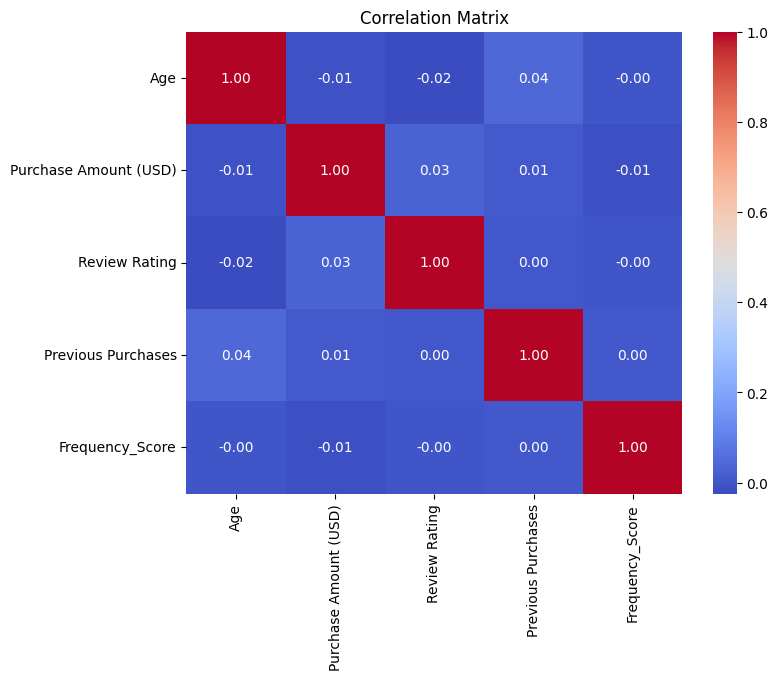

In [ ]:
# correlation matrix plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()



**Subscription Analysis**

findings: Difference is minimal.

In [ ]:
# Subscription Analysis: Do subscribers actually behave like loyal customers?
df.groupby("Subscription Status").agg({
    "Purchase Amount (USD)": ["mean","median"],
    "Previous Purchases": "mean",
    "Review Rating": "mean",
    "Frequency_Score": "mean"
}).round(2)

Purchase Amount (USD)        Previous Purchases  \
                                     mean median               mean   
Subscription Status                                                   
No                                  59.87   60.0              25.08   
Yes                                 59.49   60.0              26.08   

                    Review Rating Frequency_Score  
                             mean            mean  
Subscription Status                                
No                           3.75           17.29  
Yes                          3.75           17.95

**Discount Analysis**

In [ ]:
# Discount Analysis: Doe discount customers have lower purchase history, lower frequency of purchase and lower satisfaction?
df.groupby("Discount Applied").agg({
    "Purchase Amount (USD)": ["mean","median"],
    "Previous Purchases": "mean",
    "Review Rating": "mean",
    "Frequency_Score": "mean"
}).round(2)

Purchase Amount (USD)        Previous Purchases  \
                                  mean median               mean   
Discount Applied                                                   
No                               60.13   60.0              25.06   
Yes                              59.28   60.0              25.74   

                 Review Rating Frequency_Score  
                          mean            mean  
Discount Applied                                
No                        3.76           17.41  
Yes                       3.74           17.56

**Frequency Analysis**

In [ ]:
# Frequency Analysis: To assess, whether frequency contributes to loyalty.
df.groupby("Frequency of Purchases").agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean",
    "Review Rating": "mean"
}).sort_values(
    by="Previous Purchases",
    ascending=False
).round(2)

,Purchase Amount (USD),Previous Purchases,Review Rating
Frequency of Purchases,,,
Quarterly,60.03,25.89,3.75
Weekly,58.97,25.77,3.76
Monthly,59.33,25.28,3.77
Fortnightly,59.88,25.03,3.73
Annually,60.17,24.56,3.76


**Category Analysis**

In [ ]:
# Category Analysis: Which categories are associated with long term customers?
df.groupby("Category").agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean",
    "Review Rating": "mean"
}).sort_values(
    by="Previous Purchases",
    ascending=False
).round(2)

,Purchase Amount (USD),Previous Purchases,Review Rating
Category,,,
Accessories,59.84,25.73,3.77
Footwear,60.26,25.23,3.79
Clothing,60.03,25.20,3.72
Outerwear,57.17,24.96,3.75


**Age Analysis**

In [ ]:
# Age Analysis: Ideal Customer Profile

df.groupby(
    pd.cut(
        df["Age"],
        bins=[18,25,35,45,55,65,100]
    )
).agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean"
}).round(2)

/tmp/ipykernel_1709/570951209.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,Purchase Amount (USD),Previous Purchases
Age,,
"(18, 25]",60.74,25.13
"(25, 35]",59.76,24.76
"(35, 45]",59.31,25.17
"(45, 55]",60.58,25.42
"(55, 65]",59.14,26.21
"(65, 100]",58.88,26.15


**Frequency vs Discount Usage:**
Frequency Has Almost No Relationship With Discount Usage

In [ ]:
df.groupby("Frequency of Purchases")["Discount Applied"].value_counts(normalize=True).mul(100).round(2)

Frequency of Purchases  Discount Applied
Annually                No                  58.39
                        Yes                 41.61
Fortnightly             No                  56.93
                        Yes                 43.07
Monthly                 No                  57.14
                        Yes                 42.86
Quarterly               No                  56.50
                        Yes                 43.50
Weekly                  No                  56.59
                        Yes                 43.41
Name: proportion, dtype: float64

**Subscription Status vs Discount Applied:**
Subscription Status and Discount Applied are not Independent.


> `Every subscriber receives a discount.`



In [ ]:
pd.crosstab(
    df["Subscription Status"],
    df["Discount Applied"],
    normalize="index"
)*100

Discount Applied,No,Yes
Subscription Status,,
No,78.082192,21.917808
Yes,0.000000,100.000000


**category vs discount:**
The discount program is being used almost equally across all categories. Categories doesn't Explain Discount Usage

In [ ]:
pd.crosstab(
    df["Category"],
    df["Discount Applied"],
    normalize="index"
)*100

Discount Applied,No,Yes
Category,,
Accessories,56.209677,43.790323
Clothing,57.915947,42.084053
Footwear,56.761269,43.238731
Outerwear,55.555556,44.444444


# **FEATURE ENGINEERING**

**Feature 1: Frequency Score (how often customer buys the brand?)**

We have already created this feature in our EDA section

```
freq_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

df["Frequency_Score"] = (
    df["Frequency of Purchases"]
    .map(freq_map)
)
```



**Feature 2: Discount Dependency Score (Are customers loyal or only buying when discounts are offered?)**

In [ ]:
# 1 = Customer didn't use discount and 0 = Customer used discount
# Strong indication that discount influenced purchase
df["Discount_Independence"] = (
    df["Discount Applied"]
    .map({
        "No": 1,
        "Yes": 0
    })
)

**Feature 3: Satisfaction Flag (Should satisfied customers be given more value?)**

**Note:** *Satisfaction_Flag was created but during the later stages of the project, we realized that satisfaction did not significantly contribute towards customer value or loyalty. Satisfaction_Flag has been kept an engineered feature but was not used in the final scoring features or business logic.*

In [ ]:
# Review Rating ranges from 2.5 to 5.
# We set a threshold that if rating value is more than 4, then the customer is satisfies, else unsatisfied.

df["Satisfaction_Flag"] = np.where(df["Review Rating"] >= 4, "Satisfied", "Unsatisfied")

**Normalize Variables**

In [ ]:
# Variables ("Previous Purchases", "Frequency_Score", "Purchase Amount (USD)","Review Rating") had different scales.
# We normalize them using min max scaler.

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df[[
    "Prev_Norm",
    "Freq_Norm",
    "Spend_Norm",
    "Rating_Norm"
]] = scaler.fit_transform(
    df[[
        "Previous Purchases",
        "Frequency_Score",
        "Purchase Amount (USD)",
        "Review Rating"
    ]]
)

### **LOYALTY DEFINITIONS**

This project requires two competing definitions

**Feature 4: Loyalty Definition A (based on Behavioral Loyalty)**

This definition has been defined based on 2 factors

`Previous Purchases + Frequency Score`

Previous Purchases is a direct measure of repeat behavior. Here we assign weightage to each factor(**0.6 to Previous Purchases and 0.4 to Frequency score**). We assigned more weightage to Previous Purchases because historical behaviour is more reliable than purchasing frequency.

eg: customer X is more loyal if his total previous purchases is 50, and is buying on a monthly basis. whereas customer Z is less loyal if his total previous purchases is only 4, but buying on weekly basis.




In [ ]:
# Loyalty A formula
df["Loyalty_A"] = (0.6 * df["Prev_Norm"] + 0.4 * df["Freq_Norm"])

**Feature 5: Loyalty Definition B (Relationship Loyalty)**

A loyal customer buys repeatedly, is satisfied, doesn't require discounts.

We assign weightage to variables

- Previous Purchases (0.5) = strongest signal.
- Review Rating (0.3) = shows satisfaction level.
- Discount Independence (0.2) = shows intention to buy without discounts.

In [ ]:
# Loyalty B formula
df["Loyalty_B"] = (
      0.5 * df["Prev_Norm"]
    + 0.3 * df["Rating_Norm"]
    + 0.2 * df["Discount_Independence"]
)

**Feature 6: Customer Value Score (Who are the most valuable customers)?**

**Value = Revenue Potential**

**Assumption:** We do not have any data on total lifetime spend of a customer. We are assuming that customers spending more today are generally more valuable overall and the variables used have been given weightage accordingly.

Variables used: Purchase Amount, Previous Purchases, Frequency Score

In [ ]:
df["Customer_Value_Score"] = (
      0.5 * df["Spend_Norm"]
    + 0.3 * df["Prev_Norm"]
    + 0.2 * df["Freq_Norm"]
)

**Feature 7: Value Tier (segments)**

*   Low Value:	Weak customers
*   Medium Value:	Average customers
*   High Value:	Strong customers
*   VIP:	Best customers

used qcut to create balanced customer groups for easy comparision and analysis.





In [ ]:
df["Value_Tier"] = pd.qcut(
    df["Customer_Value_Score"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

**Feature 8: Organic Demand Score(Which customers buy because they like the brand rather than because of discounts?)**

can be used as a secondary feature for Geographic Opportunity Analysis

In [ ]:
df["Organic_Demand_Score"] = (
      0.45 * df["Prev_Norm"]
    + 0.35 * df["Freq_Norm"]
    + 0.20 * df["Discount_Independence"]
)

**Feature 9: Regional Opportunity Score(Regions with high purchase value, high purchase history and low discount dependence)**

can be included to visualize top regions based on variables used

weights assigned based on assumed business logic

In [ ]:
df["Regional_Opportunity_Score"] = (
    0.30 * df["Spend_Norm"]
    + 0.30 * df["Prev_Norm"]
    + 0.20 * df["Discount_Independence"]
    + 0.20 * df["Organic_Demand_Score"]
)

**Loyalty Tiers**

In [ ]:
# for Loyalty A
df["Loyalty_A_Tier"] = pd.qcut(
    df["Loyalty_A"],
    q=4,
    labels=[
        "Low Loyalty",
        "Medium Loyalty",
        "High Loyalty",
        "Champion"
    ]
)


#for Loyalty B
df["Loyalty_B_Tier"] = pd.qcut(
    df["Loyalty_B"],
    q=4,
    labels=[
        "Low Loyalty",
        "Medium Loyalty",
        "High Loyalty",
        "Champion"
    ]
)

**Compare Loyalty Definitions**

**findings:**

1.   Purchase Amount is basically flat in both definitions. It doesnt seem useful for choosing between Loyalty A and B.
2.   Previous purchases seems a better factor. More previous purchases means more repeat buying behavior.



In [ ]:
comparison_A = df.groupby(
    "Loyalty_A_Tier"
).agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean"
})

comparison_B = df.groupby(
    "Loyalty_B_Tier"
).agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean"
})

print("\nLOYALTY A")
print(comparison_A)

print("\nLOYALTY B")
print(comparison_B)

# Purchase Amount is NOT useful for choosing between Loyalty A and B.


LOYALTY A
                Purchase Amount (USD)  Previous Purchases
Loyalty_A_Tier                                           
Low Loyalty                 60.498978            9.194274
Medium Loyalty              58.384065           21.049030
High Loyalty                60.148414           31.895599
Champion                    60.031056           39.451346

LOYALTY B
                Purchase Amount (USD)  Previous Purchases
Loyalty_B_Tier                                           
Low Loyalty                 59.613333           11.690256
Medium Loyalty              59.231795           20.402051
High Loyalty                59.554872           29.869744
Champion                    60.657436           39.444103


/tmp/ipykernel_1709/714789983.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison_A = df.groupby(
/tmp/ipykernel_1709/714789983.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison_B = df.groupby(


Loyalty A has larger spread than loyalty B between low and champion customers.

**Loyalty Definition A** was selected because it relies on the two strongest behavioral indicators available in the dataset: purchase frequency and purchase history. It creates stronger customer separation and aligns with repeat-purchase behavior more strongly.

**Value_Tier Count**

In [ ]:
df["Value_Tier"].value_counts()

,count
Value_Tier,
Low Value,975
Medium Value,975
High Value,975
VIP,975


In [ ]:
df.groupby("Value_Tier").agg({
    "Purchase Amount (USD)": "mean",
    "Previous Purchases": "mean",
    "Frequency_Score": "mean"
}).round(2)

/tmp/ipykernel_1709/4066792415.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Value_Tier").agg({


,Purchase Amount (USD),Previous Purchases,Frequency_Score
Value_Tier,,,
Low Value,34.50,16.91,10.73
Medium Value,51.25,23.95,15.94
High Value,69.24,25.94,17.80
VIP,84.06,34.61,25.42


The Value Score successfully identifies customers who:

- Spend more
- Purchase more frequently
- Have longer purchase histories

**Raname variable names for accurate SQL analysis**

space has been replaced with underscore and removed "()" symbol

In [ ]:
df.columns = (
    df.columns
      .str.replace(' ', '_', regex=False)
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
)

print(df.columns.tolist())

['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases', 'Frequency_Score', 'Discount_Independence', 'Satisfaction_Flag', 'Prev_Norm', 'Freq_Norm', 'Spend_Norm', 'Rating_Norm', 'Loyalty_A', 'Loyalty_B', 'Customer_Value_Score', 'Value_Tier', 'Organic_Demand_Score', 'Regional_Opportunity_Score', 'Loyalty_A_Tier', 'Loyalty_B_Tier']


**Export to csv for Customer Segmentation & Analysis in SQL**

In [ ]:
df.to_csv(
    "customer_features.csv",
    index=False
)